# Khám phá dữ liệu Abalone

Notebook này gộp ba phần đầu của quy trình làm đồ án: `Load Data`, `Initial Data Analysis` và `Exploratory Data Analysis (EDA)` cho bộ dữ liệu Abalone.

## 1. Mục tiêu bài toán

- Bài toán của nhóm là **hồi quy**, với mục tiêu dự đoán số vòng tăng trưởng `Rings` của abalone.
- Theo mô tả phổ biến của bộ dữ liệu, tuổi thực tế có thể suy ra gần đúng bằng công thức: `Age = Rings + 1.5`.
- Mục tiêu của notebook này là hiểu dữ liệu, phát hiện vấn đề chất lượng dữ liệu, tìm tín hiệu liên quan đến `Rings`, và rút ra các quyết định tiền xử lý có cơ sở.

## 2. Chuẩn bị thư viện

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Dung helper load du lieu tu src/data/load_data.py
from src.data.load_data import ABALONE_COLUMNS, load_abalone_data

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)


## 3. Load data

In [ ]:
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'abalone.csv'

# Goi ham load_abalone_data() trong src/data/load_data.py
columns = ABALONE_COLUMNS.copy()
df = load_abalone_data(DATA_PATH, columns=columns)
display(df.head())


,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 4. Mô tả dữ liệu

Bộ dữ liệu Abalone gồm một biến phân loại (`Sex`) và các biến đo lường kích thước, khối lượng của con bào ngư. Biến đích là `Rings`.

In [3]:
data_dictionary = pd.DataFrame(
    {
        'column': columns,
        'description': [
            'Giới tính của abalone: M (male), F (female), I (infant).',
            'Chiều dài lớn nhất của vỏ.',
            'Đường kính vuông góc với chiều dài.',
            'Chiều cao của abalone cùng phần thịt trong vỏ.',
            'Khối lượng toàn bộ con abalone.',
            'Khối lượng phần thịt sau khi tách vỏ.',
            'Khối lượng nội tạng sau khi lấy máu.',
            'Khối lượng vỏ sau khi sấy khô.',
            'Số vòng tăng trưởng trên vỏ; là biến mục tiêu của bài toán.',
        ],
    }
)

display(data_dictionary)

,column,description
0,Sex,"Giới tính của abalone: M (male), F (female), I..."
1,Length,Chiều dài lớn nhất của vỏ.
2,Diameter,Đường kính vuông góc với chiều dài.
3,Height,Chiều cao của abalone cùng phần thịt trong vỏ.
4,WholeWeight,Khối lượng toàn bộ con abalone.
5,ShuckedWeight,Khối lượng phần thịt sau khi tách vỏ.
6,VisceraWeight,Khối lượng nội tạng sau khi lấy máu.
7,ShellWeight,Khối lượng vỏ sau khi sấy khô.
8,Rings,Số vòng tăng trưởng trên vỏ; là biến mục tiêu ...


## 5. Initial data analysis

Phần này kiểm tra kích thước dữ liệu, kiểu dữ liệu, và thống kê mô tả cơ bản trước khi đi vào EDA sâu hơn.

In [4]:
print(f'Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột')
print('\nKiểu dữ liệu của từng cột:')
display(df.dtypes.to_frame('dtype'))

buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

display(df.describe(include='all').T)

Kích thước dữ liệu: 4177 dòng, 9 cột

Kiểu dữ liệu của từng cột:


,dtype
Sex,object
Length,float64
Diameter,float64
Height,float64
WholeWeight,float64
ShuckedWeight,float64
VisceraWeight,float64
ShellWeight,float64
Rings,int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sex            4177 non-null   object 
 1   Length         4177 non-null   float64
 2   Diameter       4177 non-null   float64
 3   Height         4177 non-null   float64
 4   WholeWeight    4177 non-null   float64
 5   ShuckedWeight  4177 non-null   float64
 6   VisceraWeight  4177 non-null   float64
 7   ShellWeight    4177 non-null   float64
 8   Rings          4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sex,4177,3,M,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,4177.0,NaN,NaN,NaN,0.523992,0.120093,0.075,0.45,0.545,0.615,0.815
Diameter,4177.0,NaN,NaN,NaN,0.407881,0.09924,0.055,0.35,0.425,0.48,0.65
Height,4177.0,NaN,NaN,NaN,0.139516,0.041827,0.0,0.115,0.14,0.165,1.13
WholeWeight,4177.0,NaN,NaN,NaN,0.828742,0.490389,0.002,0.4415,0.7995,1.153,2.8255
ShuckedWeight,4177.0,NaN,NaN,NaN,0.359367,0.221963,0.001,0.186,0.336,0.502,1.488
VisceraWeight,4177.0,NaN,NaN,NaN,0.180594,0.109614,0.0005,0.0935,0.171,0.253,0.76
ShellWeight,4177.0,NaN,NaN,NaN,0.238831,0.139203,0.0015,0.13,0.234,0.329,1.005
Rings,4177.0,NaN,NaN,NaN,9.933684,3.224169,1.0,8.0,9.0,11.0,29.0


## 6. Missing values và duplicate

In [5]:
missing_summary = df.isna().sum().to_frame('missing_count')
missing_summary['missing_ratio'] = (missing_summary['missing_count'] / len(df)).round(4)

duplicate_count = df.duplicated().sum()

display(missing_summary)
print(f'Số dòng trùng lặp: {duplicate_count}')

,missing_count,missing_ratio
Sex,0,0.0
Length,0,0.0
Diameter,0,0.0
Height,0,0.0
WholeWeight,0,0.0
ShuckedWeight,0,0.0
VisceraWeight,0,0.0
ShellWeight,0,0.0
Rings,0,0.0


Số dòng trùng lặp: 0


## 7. Phân phối biến mục tiêu `Rings`

,count,mean,std,min,25%,50%,75%,max,skewness
Rings,4177.0,9.933684,3.224169,1.0,8.0,9.0,11.0,29.0,1.114102


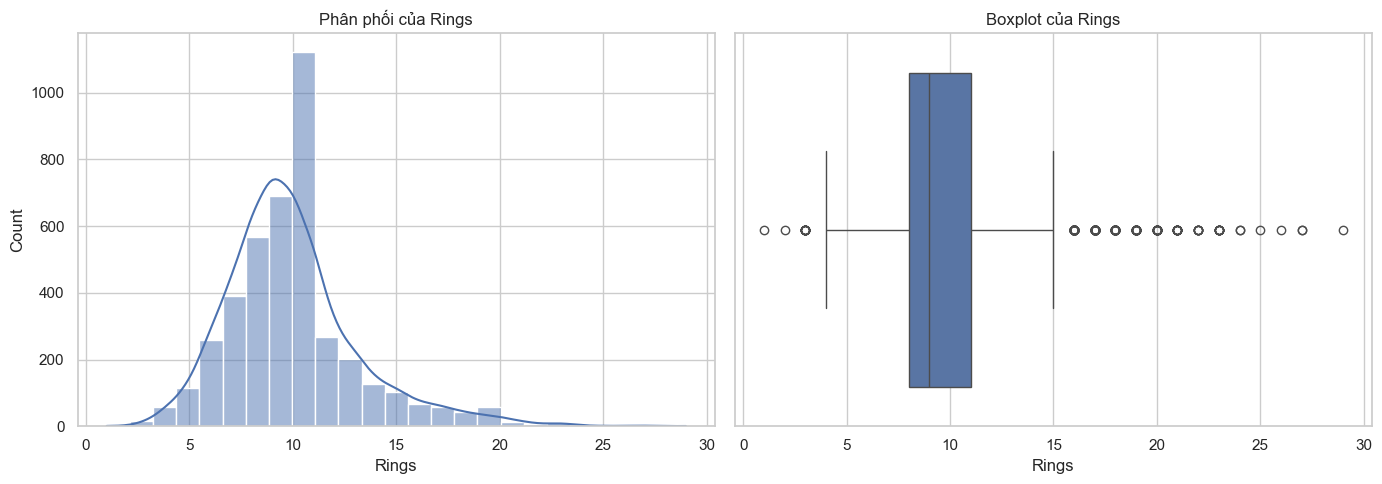

In [6]:
rings_summary = df['Rings'].describe().to_frame().T
rings_summary['skewness'] = df['Rings'].skew()
display(rings_summary)

# Vẽ biểu đồ phân phối và boxplot cho biến Rings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Rings'], kde=True, bins=25, ax=axes[0])
axes[0].set_title('Phân phối của Rings')
# ax=axes[1] để chỉ định vẽ boxplot trên trục thứ 2 của subplot
sns.boxplot(x=df['Rings'], ax=axes[1])
axes[1].set_title('Boxplot của Rings')
plt.tight_layout()
plt.show()

## 8. Phân tích biến phân loại `Sex`

Ngoài việc xem tần suất của từng nhóm `Sex`, ta cũng kiểm tra phân phối `Rings` theo từng nhóm để xem biến phân loại này có liên quan đến biến mục tiêu hay không.

,Sex,count
0,M,1528
1,I,1342
2,F,1307


,count,mean,median,std
Sex,,,,
F,1307,11.13,10.0,3.10
I,1342,7.89,8.0,2.51
M,1528,10.71,10.0,3.03


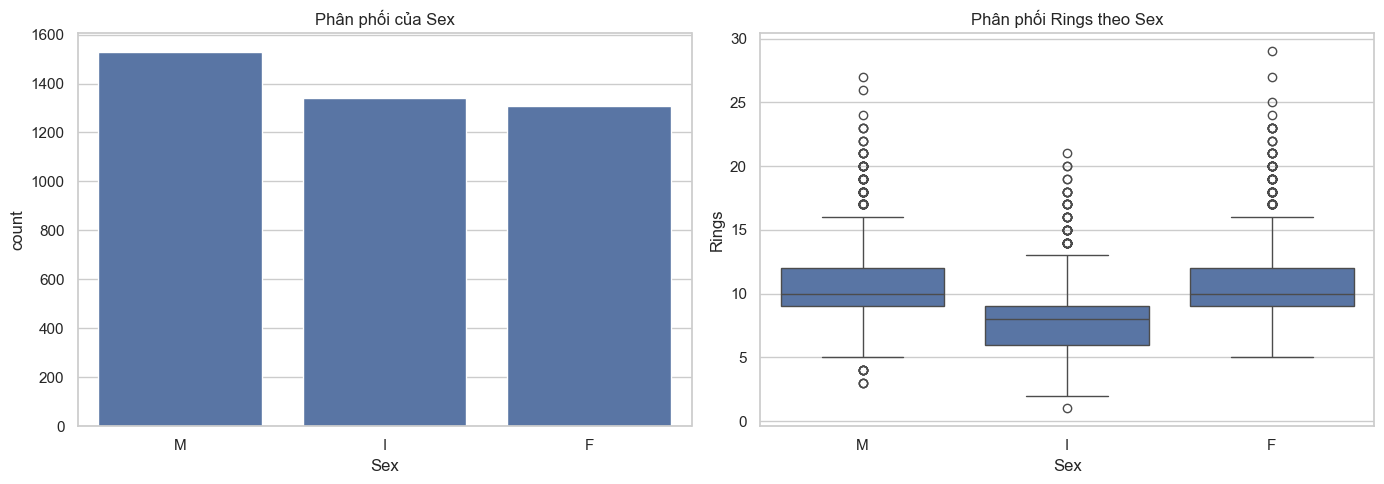

In [7]:
sex_counts = df['Sex'].value_counts().rename_axis('Sex').reset_index(name='count')
sex_target_summary = df.groupby('Sex')['Rings'].agg(['count', 'mean', 'median', 'std']).round(2)

display(sex_counts)
display(sex_target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Sex', order=df['Sex'].value_counts().index, ax=axes[0])
axes[0].set_title('Phân phối của Sex')
sns.boxplot(data=df, x='Sex', y='Rings', order=df['Sex'].value_counts().index, ax=axes[1])
axes[1].set_title('Phân phối Rings theo Sex')
plt.tight_layout()
plt.show()

## 9. Phân tích các biến số và outliers

Mục tiêu là quan sát hình dạng phân phối của các biến số, đồng thời phát hiện các giá trị ngoại lệ tiềm năng bằng quy tắc IQR.

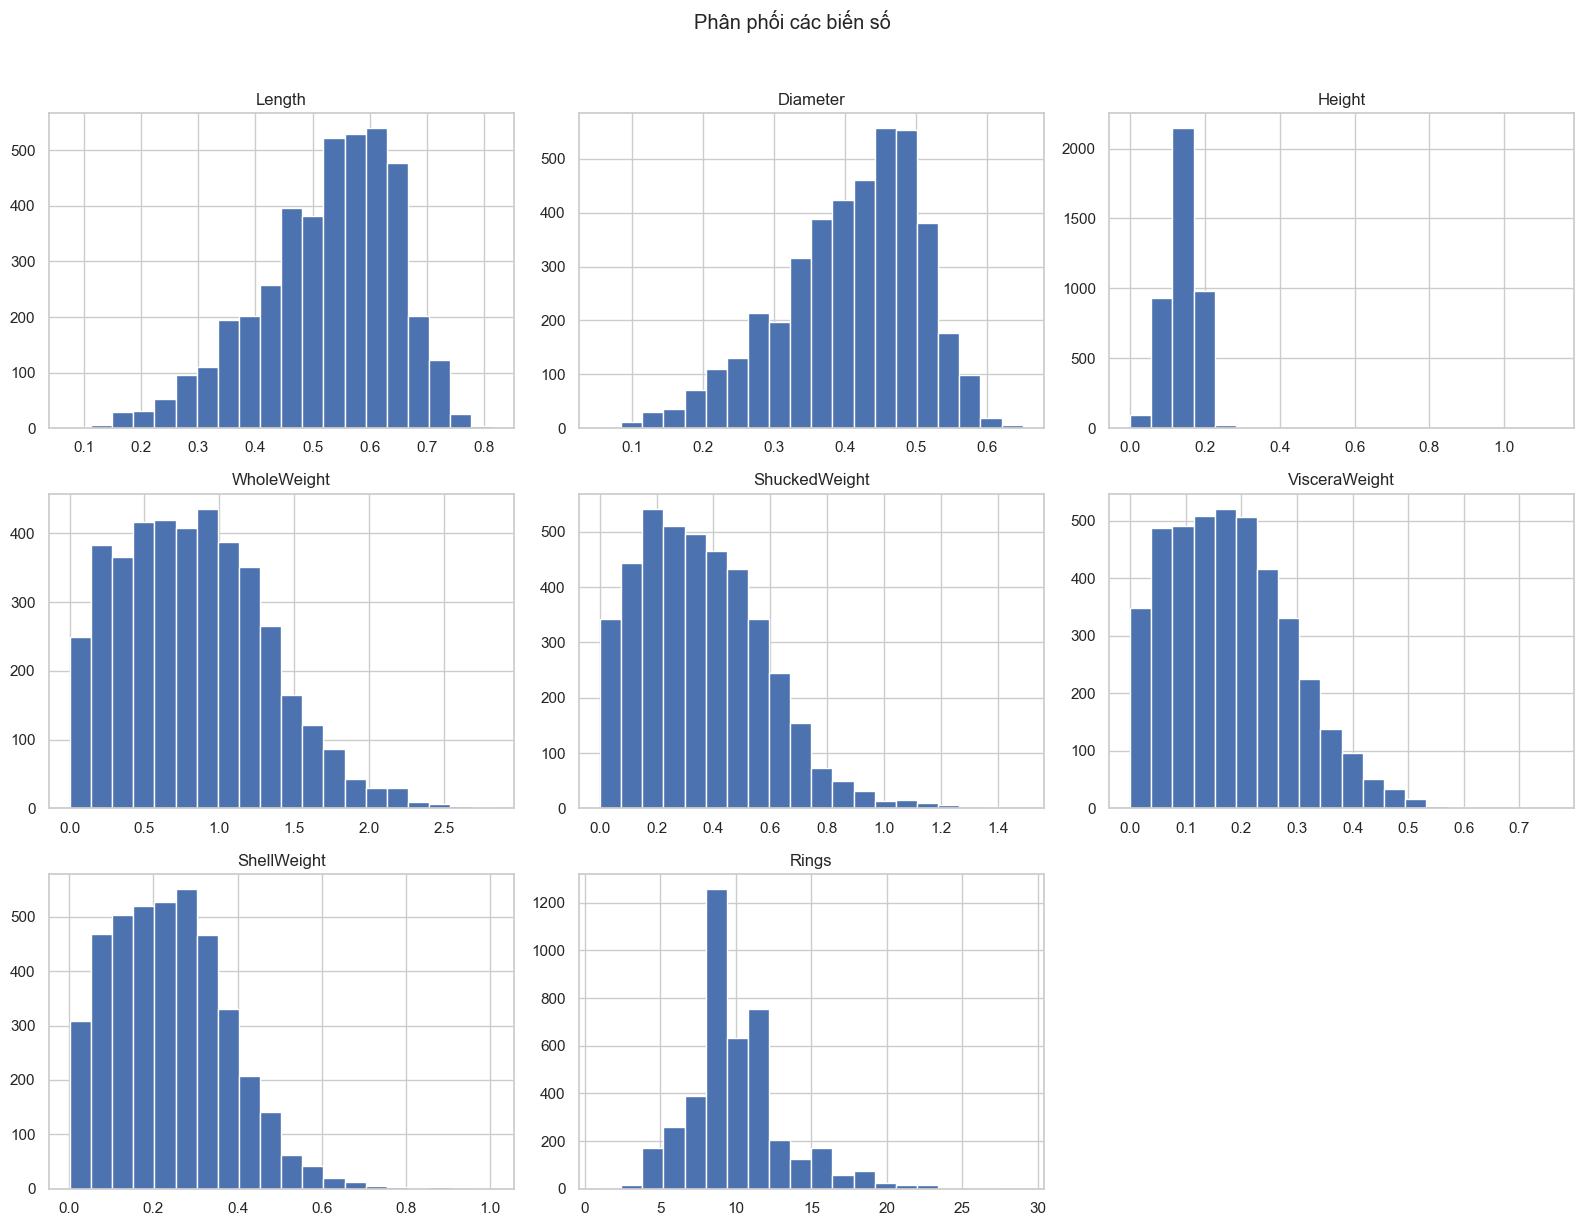

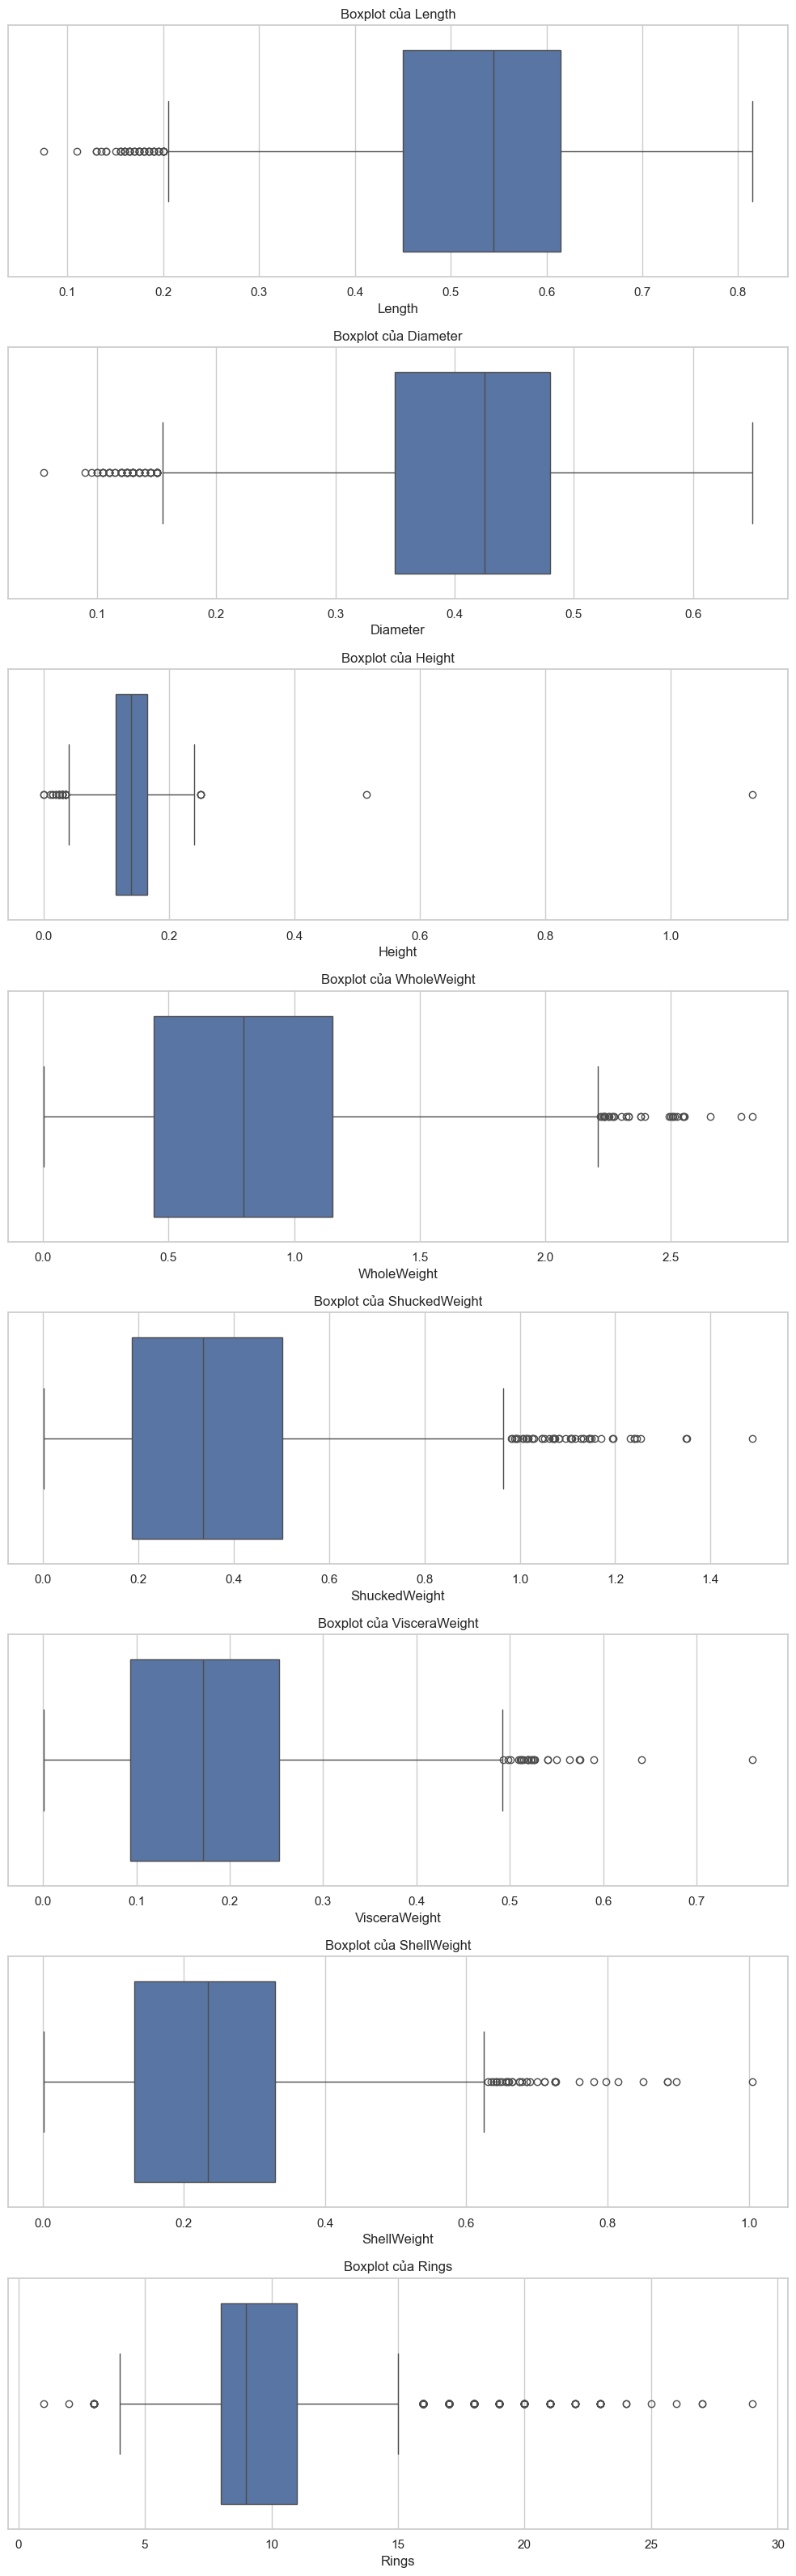

,column,lower_bound,upper_bound,outlier_count,outlier_ratio
7,Rings,3.5000,15.5000,278,0.0666
1,Diameter,0.1550,0.6750,59,0.0141
0,Length,0.2025,0.8625,49,0.0117
4,ShuckedWeight,-0.2880,0.9760,48,0.0115
6,ShellWeight,-0.1685,0.6275,35,0.0084
3,WholeWeight,-0.6258,2.2202,30,0.0072
2,Height,0.0400,0.2400,29,0.0069
5,VisceraWeight,-0.1458,0.4922,26,0.0062


In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# hist dùng để chia nhỏ phạm vi của dữ liệu thành các khoảng (bins) và đếm số lượng giá trị rơi vào mỗi khoảng đó, từ đó tạo ra biểu đồ cột thể hiện phân phối của dữ liệu.
#bins = 20 có nghĩa là chia phạm vi của dữ liệu thành 20 khoảng đều nhau.
df[numeric_cols].hist(bins=20, figsize=(16, 12))
plt.suptitle('Phân phối các biến số', y=1.02)
plt.tight_layout()
plt.show()

# Vẽ boxplot để phát hiện outliers
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 4 * len(numeric_cols)))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot của {col}')
plt.tight_layout()
plt.show()

outlier_rows = []
# Sử dụng phương pháp IQR để xác định outliers cho từng biến số
# Q1 tứ phân vị thứ nhất (25%), Q3 tứ phân vị thứ ba (75%), IQR = Q3 - Q1, sau đó xác định ngưỡng dưới và trên để phát hiện outliers.
# lower = Q1 - 1.5 * IQR, upper = Q3 + 1.5 * IQR, nếu giá trị nằm ngoài khoảng này thì được coi là outlier.
# outlier_ratio là tỷ lệ nhiễm bẩn của biến số, được tính bằng số lượng outliers chia cho tổng số dòng dữ liệu.
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append(
        {
            'column': col,
            'lower_bound': round(lower, 4),
            'upper_bound': round(upper, 4),
            'outlier_count': int(outlier_count),
            'outlier_ratio': round(outlier_count / len(df), 4),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_ratio', ascending=False)
display(outlier_summary)

## 10. Correlation và quan hệ với `Rings`

Phần này xác định những biến số có mối liên hệ mạnh hơn với `Rings`, từ đó hỗ trợ lựa chọn đặc trưng và định hướng mô hình ở giai đoạn sau.

,corr_with_rings
Rings,1.000000
ShellWeight,0.627574
Diameter,0.574660
Height,0.557467
Length,0.556720
WholeWeight,0.540390
VisceraWeight,0.503819
ShuckedWeight,0.420884


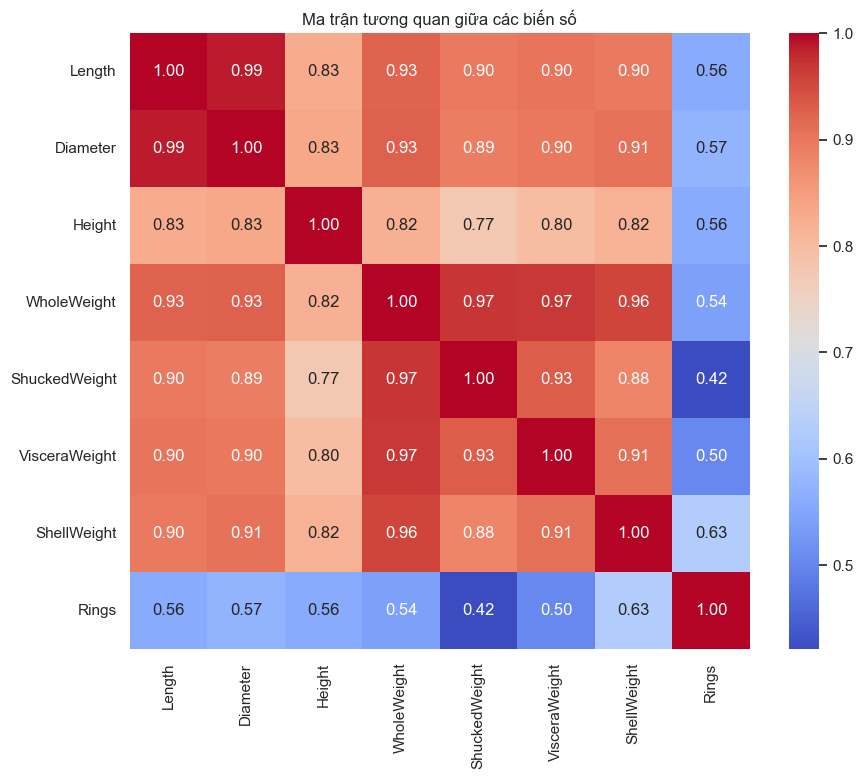

Các biến có tương quan tuyệt đối mạnh nhất với Rings: ['ShellWeight', 'Diameter', 'Height', 'Length', 'WholeWeight']


In [9]:
corr = df[numeric_cols].corr() #tính toán ma trận tương quan giữa các biến số định lượng trong DataFrame df. 
# Hàm corr() sẽ trả về một DataFrame mới chứa hệ số tương quan Pearson giữa từng cặp biến số.
corr_with_target = corr['Rings'].sort_values(ascending=False).to_frame('corr_with_rings')
display(corr_with_target)

plt.figure(figsize=(10, 8))
# annot=True để hiển thị giá trị tương quan trên mỗi ô của heatmap, cmap='coolwarm' để sử dụng bảng màu từ xanh dương (tương quan âm) đến đỏ (tương quan dương), fmt='.2f' để định dạng số thập phân với 2 chữ số sau dấu phẩy.
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

key_features = corr['Rings'].drop('Rings').abs().sort_values(ascending=False).head(5).index.tolist()
print('Các biến có tương quan tuyệt đối mạnh nhất với Rings:', key_features)

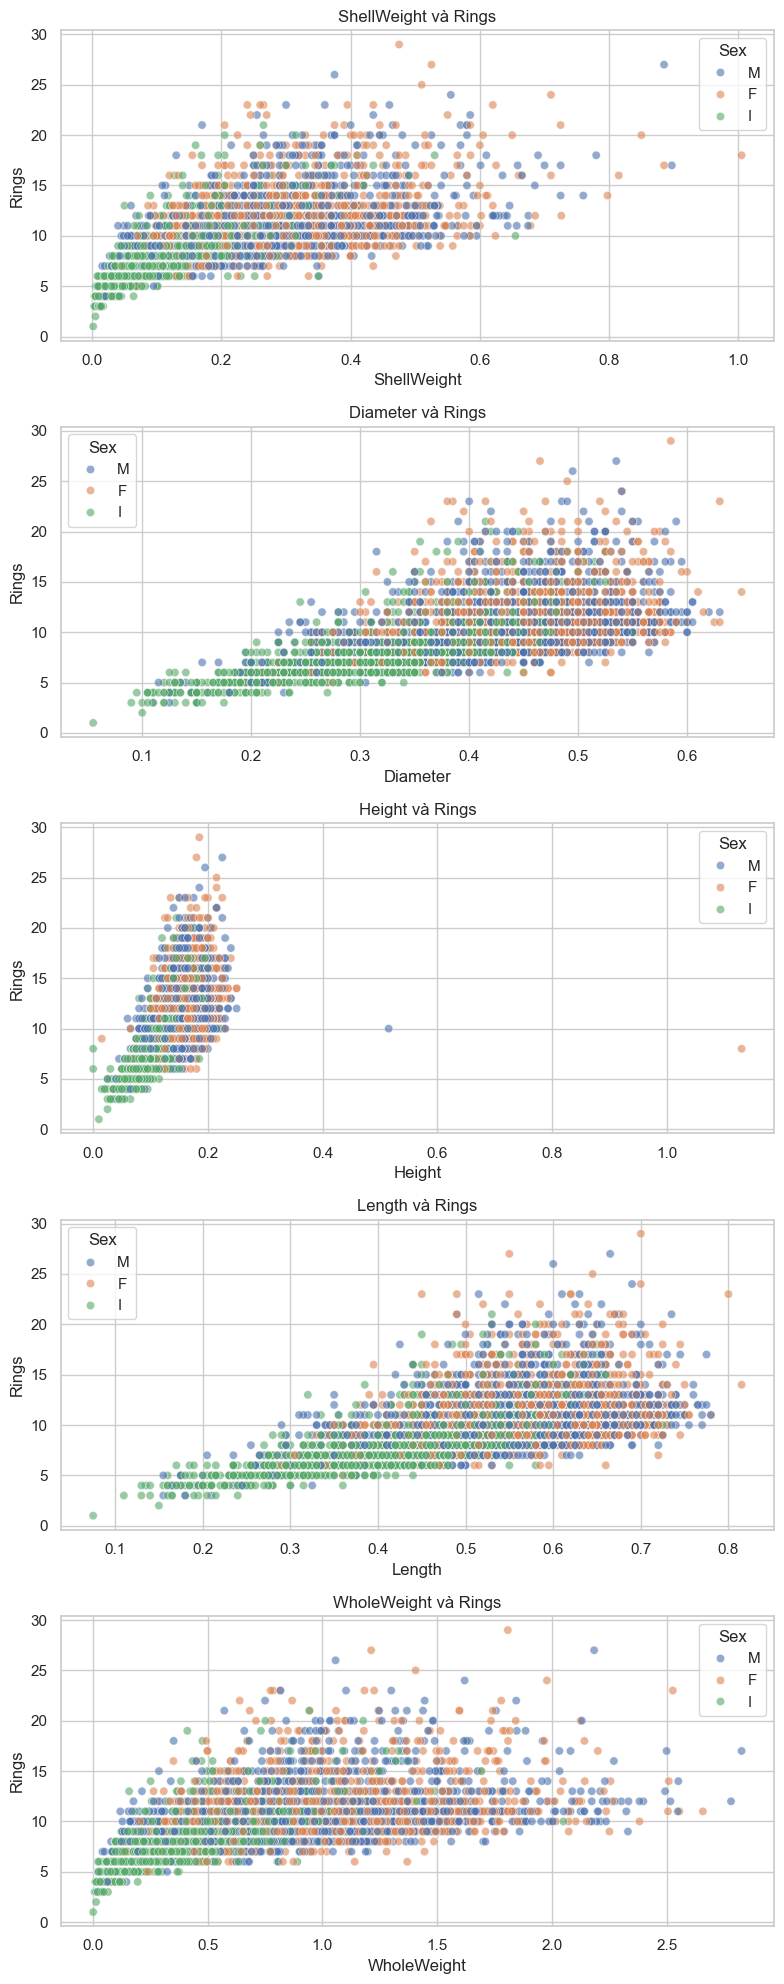

In [10]:
fig, axes = plt.subplots(len(key_features), 1, figsize=(8, 4 * len(key_features)))
for ax, col in zip(axes, key_features):
    sns.scatterplot(data=df, x=col, y='Rings', hue='Sex', alpha=0.6, ax=ax)
    ax.set_title(f'{col} và Rings')
plt.tight_layout()
plt.show()

## 11. Kết luận EDA

- Dữ liệu có kích thước vừa phải, gồm 1 biến phân loại (`Sex`) và 8 biến số, phù hợp để triển khai bài toán hồi quy với scikit-learn.
- Không xuất hiện giá trị thiếu, vì vậy bước xử lý missing value có thể chỉ cần kiểm chứng và ghi nhận, chưa cần nội suy hay loại bỏ dữ liệu.
- `Sex` có phân phối không hoàn toàn đồng đều giữa các nhóm và có liên quan nhất định đến `Rings`, nên không thể bỏ qua biến này trong mô hình.
- `Rings` và nhiều biến trọng lượng/kích thước có xuất hiện ngoại lệ và độ lệch phân phối ở mức nhất định, cần cân nhắc kỹ cách scale hoặc xử lý outlier.
- Một số biến số có tương quan với `Rings`, nhưng mối quan hệ có thể không hoàn toàn tuyến tính, do đó nên thử cả nhóm mô hình tuyến tính và phi tuyến.

## 12. Các quyết định tiền xử lý rút ra từ EDA

- Cần mã hóa biến `Sex` trước khi huấn luyện mô hình; nên thử `One-Hot Encoding` để tránh áp đặt thứ tự giả.
- Không cần xử lý missing value theo kiểu điền khuyết ở thời điểm hiện tại, nhưng vẫn phải giữ bước kiểm tra này trong pipeline để chứng minh chất lượng dữ liệu.
- Nên chia dữ liệu theo tỷ lệ `70/30` đúng yêu cầu đề bài và cố định `random_state = 42` để đảm bảo tái lập kết quả.
- Nên chuẩn hóa dữ liệu cho các mô hình nhạy với scale như `KNeighborsRegressor`, `SVR`, `LinearSVR`, `SGDRegressor` và `MLPRegressor`.
- Cần thử ít nhất hai hướng xử lý ngoại lệ hoặc phân phối lệch: giữ nguyên dữ liệu gốc làm baseline và thử thêm một phương án như `RobustScaler`, log-transform cho các biến trọng lượng, hoặc lọc outlier theo IQR.
- Có thể cân nhắc feature engineering nhẹ ở notebook tiền xử lý, ví dụ tạo các tỷ lệ giữa khối lượng và kích thước, nhưng mọi đặc trưng mới phải được giải thích dựa trên EDA.